In [7]:
import os
import re
import csv
from collections import defaultdict
from statistics import mean

def parse_log_file_last_metrics(path):
    """从 log 文件末尾提取最后一次 eval 的指标（支持科学计数法）"""
    eval_metrics = {}
    with open(path, encoding="utf-8") as f:
        lines = f.readlines()

    i = len(lines) - 1
    while i >= 0:
        if lines[i].strip().startswith("start to eval"):
            # hit20
            if i + 1 < len(lines) and lines[i+1].startswith("hit20"):
                m = re.search(r"hit20\s+([0-9.+-eE]+)", lines[i+1])
                if m:
                    eval_metrics["hit20"] = float(m.group(1))
            # hit50
            if i + 2 < len(lines) and lines[i+2].startswith("hit50"):
                m = re.search(r"hit50\s+([0-9.+-eE]+)", lines[i+2])
                if m:
                    eval_metrics["hit50"] = float(m.group(1))
            # hit100
            if i + 3 < len(lines) and lines[i+3].startswith("hit100"):
                m = re.search(r"hit100\s+([0-9.+-eE]+)", lines[i+3])
                if m:
                    eval_metrics["hit100"] = float(m.group(1))
            # 复合指标
            if i + 4 < len(lines) and lines[i+4].startswith("roc_auc"):
                nums = re.findall(r"[-+]?\d+(?:\.\d+)?(?:[eE][-+]?\d+)?", lines[i+4])
                if len(nums) >= 4:
                    fields = ['roc_auc', 'pr_auc', 'f1', 'mrr']
                    result_dict = dict(zip(fields, map(float, nums[-4:])))
                    eval_metrics.update(result_dict)
            if eval_metrics:
                break
        i -= 1
    return eval_metrics


# ==== 参数 ====
dataset = "twitter"
ratio = 0.3
convergences = [0.67, 0.70, 0.73]
alphas = [15, 16, 17, 17.5, 18, 18.5, 19, 19.5] # , 20, 20.5, 21, 21.5, 22, 22.5, 23, 24]
seed = 1

log_base_dir = "."
output_dir = "./results"
os.makedirs(output_dir, exist_ok=True)

ALL_METRICS = ['hit20', 'hit50', 'hit100', 'roc_auc', 'pr_auc', 'f1', 'mrr']

metric_bucket = defaultdict(list)
metric_keys = set()

# ==== 遍历日志 ====
for conv in convergences:
    for alpha in alphas:
        fname = f"r{ratio}_conv{conv}_alpha{alpha}.log"
        log_path = os.path.join(log_base_dir, fname)
        key = (ratio, conv, alpha)

        if not os.path.isfile(log_path):
            print(f"[WARN] 缺失: {log_path}")
            metrics = {k: 0.0 for k in ALL_METRICS}
            metric_bucket[key].append(metrics)
            metric_keys.update(metrics.keys())
            continue

        metrics = parse_log_file_last_metrics(log_path)
        if not metrics:
            print(f"[WARN] 无指标: {log_path}")
            metrics = {k: 0.0 for k in ALL_METRICS}
        metric_bucket[key].append(metrics)
        metric_keys.update(metrics.keys())

# ==== 写入 CSV ====
csv_path = os.path.join(output_dir, f"{dataset}_grid_result_logs3.csv")
metric_keys = sorted(metric_keys)
header = ["split_ratio", "convergence", "alpha"] + metric_keys

with open(csv_path, "w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=header)
    writer.writeheader()
    for key, metrics_list in metric_bucket.items():
        ratio, conv, alpha = key
        row = {"split_ratio": ratio, "convergence": conv, "alpha": alpha}
        for k in metric_keys:
            vals = [m[k] for m in metrics_list if k in m]
            row[k] = f"{round(round(mean(vals), 4) * 100, 2)}" if vals else "0.0"
        writer.writerow(row)

print(f"[INFO] 写入完毕: {csv_path}")


[INFO] 写入完毕: ./results/twitter_grid_result_logs3.csv


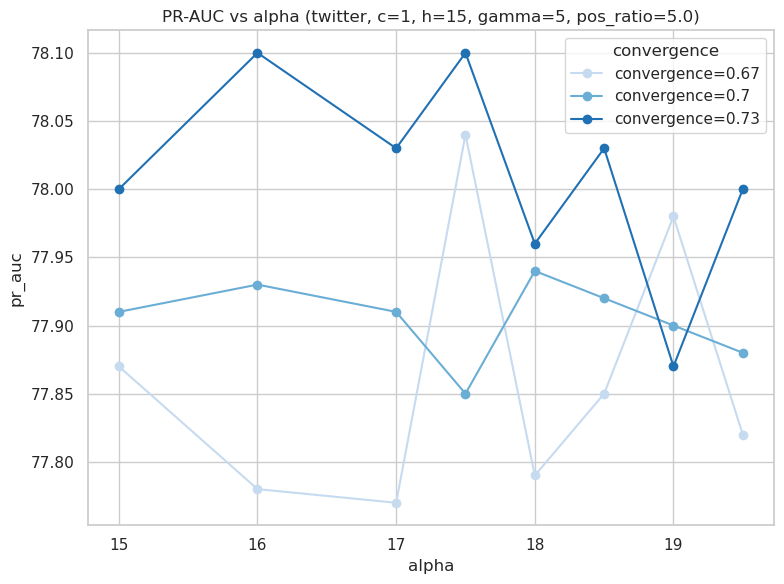

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === 读取数据 ===
csv_path = "./results/twitter_grid_result_logs3.csv"
df = pd.read_csv(csv_path)
df["pr_auc"] = df["pr_auc"].astype(float)

# === 绘图 ===
sns.set(style="whitegrid")
plt.figure(figsize=(8, 6))

palette = sns.color_palette("Blues", n_colors=len(df["convergence"].unique()))

for i, conv in enumerate(sorted(df["convergence"].unique())):
    sub = df[df["convergence"] == conv].sort_values("alpha")
    plt.plot(
        sub["alpha"],
        sub["pr_auc"],
        marker="o",
        color=palette[i],
        label=f"convergence={conv}"
    )

plt.title("PR-AUC vs alpha (twitter, c=1, h=15, gamma=5, pos_ratio=5.0)")
plt.xlabel("alpha")
plt.ylabel("pr_auc")
plt.legend(title="convergence")
plt.grid(True)
plt.tight_layout()
plt.show()
